- Выбираем две функции:

- Константная: $f(x_1,x_2)= 1$;

- оракул для неё $U_f = I \oplus I \oplus X $(посчитано ручками на бумаге, проверено с файлом);


- Сбалансированная: $f(x_1,x_2)=x_1$;

- оракул для неё $ U_f = CX (x_1,y) $(посчитано ручками на бумаге)



In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
import matplotlib.pyplot as plt

SHOTS = 4096

In [2]:
# Пусть kind - принимает либо constant, либо balanced (иначе - ошибка)
# Тогда функция будет строить соответствующий оракул U_f
def make_oracle(kind: str) -> QuantumCircuit:
    qc = QuantumCircuit(3, name=f"Uf_{kind}")
    if kind == "constant": # так как U_f(const) = I \oplus I \oplus X , 
        qc.x(2)
    elif kind == "balanced": # так как U_f(balanced) = CX(x1,y), то, соответственно, применяем CX
        qc.cx(0, 2)
    else:
        raise ValueError("Error") #защита от других аргументов
    return qc

#Построим саму схему алгоритма
def make_dj_circuit(kind: str) -> QuantumCircuit:
    qc = QuantumCircuit(3, 2) # в результате будем измерять 2 бита, поэтому объявляем столько классических


    qc.h(0)
    qc.h(1)
    qc.x(2)
    qc.h(2)
    # первый слой - применяем ко всем оператор Адамара, а к q_3 - X, так как изначально он в состоянии \0>
    
    # теперь стоим функцию оракула
    qc.compose(make_oracle(kind), inplace=True)

    qc.h(0)
    qc.h(1)

    # в конце - измеряем
    qc.measure(0, 0)
    qc.measure(1, 1)
    return qc

constant_circuit = make_dj_circuit("constant")
balanced_circuit = make_dj_circuit("balanced")

constant_circuit.draw("text")


┌───┐┌───┐     ┌─┐   
q_0: ┤ H ├┤ H ├─────┤M├───
     ├───┤├───┤     └╥┘┌─┐
q_1: ┤ H ├┤ H ├──────╫─┤M├
     ├───┤├───┤┌───┐ ║ └╥┘
q_2: ┤ X ├┤ H ├┤ X ├─╫──╫─
     └───┘└───┘└───┘ ║  ║ 
c: 2/════════════════╩══╩═
                     0  1

In [3]:
print("Constant oracle:")
print(make_oracle("constant").draw("text"))
print("Balanced oracle:")
print(make_oracle("balanced").draw("text"))
print("Deutsch-Jozsa, constant:")
print(constant_circuit.draw("text"))
print("Deutsch-Jozsa, balanced:")
print(balanced_circuit.draw("text"))

Constant oracle:
          
q_0: ─────
          
q_1: ─────
     ┌───┐
q_2: ┤ X ├
     └───┘
Balanced oracle:
          
q_0: ──■──
       │  
q_1: ──┼──
     ┌─┴─┐
q_2: ┤ X ├
     └───┘
Deutsch-Jozsa, constant:
     ┌───┐┌───┐     ┌─┐   
q_0: ┤ H ├┤ H ├─────┤M├───
     ├───┤├───┤     └╥┘┌─┐
q_1: ┤ H ├┤ H ├──────╫─┤M├
     ├───┤├───┤┌───┐ ║ └╥┘
q_2: ┤ X ├┤ H ├┤ X ├─╫──╫─
     └───┘└───┘└───┘ ║  ║ 
c: 2/════════════════╩══╩═
                     0  1 
Deutsch-Jozsa, balanced:
     ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐  │  └┬─┬┘└╥┘
q_1: ┤ H ├┤ H ├──┼───┤M├──╫─
     ├───┤├───┤┌─┴─┐ └╥┘  ║ 
q_2: ┤ X ├┤ H ├┤ X ├──╫───╫─
     └───┘└───┘└───┘  ║   ║ 
c: 2/═════════════════╩═══╩═
                      1   0 


In [4]:
# Сначала посмотрим, что получается в случае без шума (идеальном)
ideal_backend = AerSimulator()

# Затем смотрим результат на "реальной" машине с имитацией физического шума
fake_backend = FakeManilaV2()
noisy_backend = AerSimulator.from_backend(fake_backend)


def run_counts(circuit, backend, shots=SHOTS):
    compiled = transpile(circuit, backend)
    result = backend.run(compiled, shots=shots).result()
    return result.get_counts()

results = {}
#для примера было исполнено 4096 циклов, выводим результаты для понимания
for name, circuit in [("constant", constant_circuit), ("balanced", balanced_circuit)]:
    results[(name, "ideal")] = run_counts(circuit, ideal_backend)
    results[(name, "noisy")]= run_counts(circuit, noisy_backend)

results

{('constant', 'ideal'): {'00': 4096},
 ('constant', 'noisy'): {'00': 3929, '10': 78, '01': 87, '11': 2},
 ('balanced', 'ideal'): {'01': 4096},
 ('balanced', 'noisy'): {'01': 3936, '11': 79, '00': 77, '10': 4}}

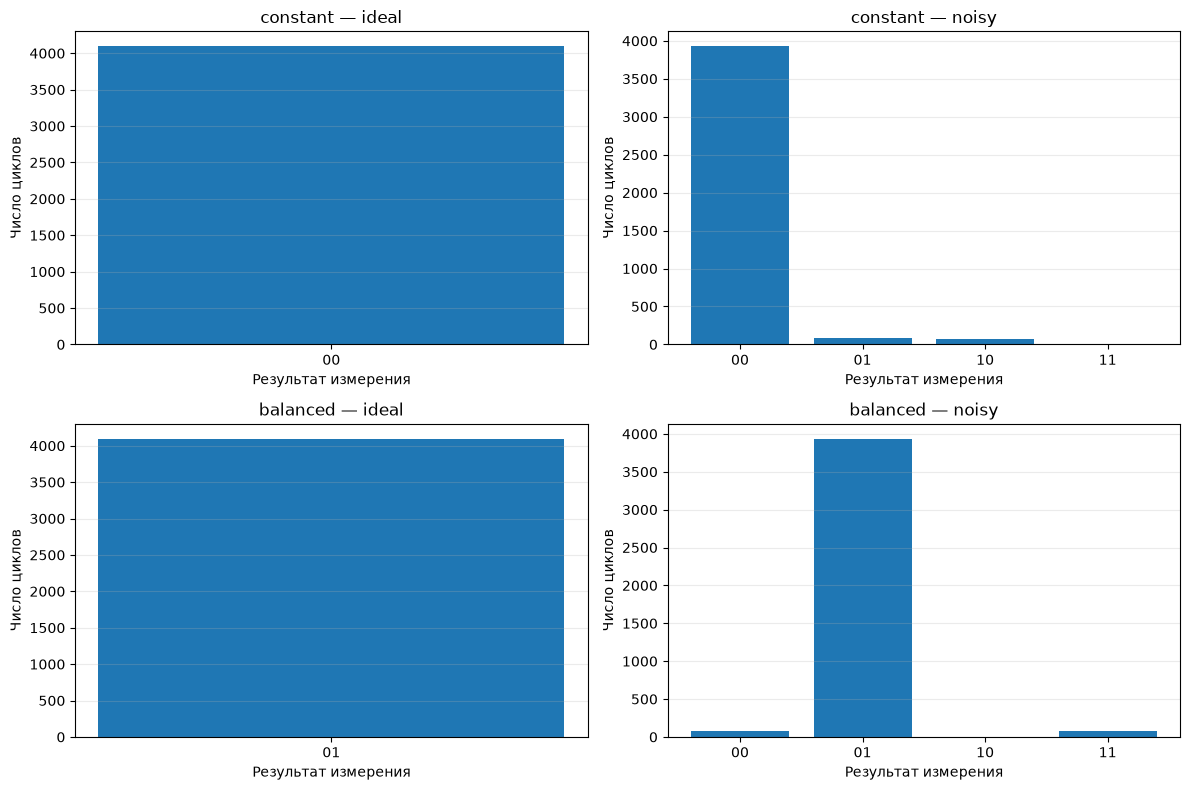

In [5]:
# визуализируем
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
for row, name in enumerate(["constant", "balanced"]):
    for col, mode in enumerate(["ideal", "noisy"]):
        counts = results[(name, mode)]
        ax = axes[row, col]
        keys = sorted(counts)
        vals = [counts[k] for k in keys]
        ax.bar(keys, vals)
        ax.set_title(f"{name} — {mode}")
        ax.set_xlabel("Результат измерения")
        ax.set_ylabel("Число циклов")
        ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Реультат


- Для константной функции - результат $| 00 \rangle $ в 100% случаях идеальной симуляции. При симуляции на реальном устройстве - появляются шумы и распределение по "неверным" состояниям, но, в целом, правильное состояние различимо статистически (поэтому берём большое количество циклов)

- Аналогичная картина для сбалансированной функции, но состояние $| 10 \rangle $ (помним, что в qiskit обратная запись) 





